<a href="https://colab.research.google.com/github/hanifanwibawa/datanaly/blob/ImputeData_Chol/ImputeData_Chol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv('/content/wahana.csv')

In [ ]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,female,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,man,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,male,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [ ]:
df.shape

(1380, 16)

In [ ]:
print (f'total baris : {df.shape[0]}')
print (f'total kolom : {df.shape[1]}')

total baris : 1380
total kolom : 16


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1380 entries, 0 to 1379
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        1380 non-null   int64  
 1   age       1380 non-null   int64  
 2   sex       1380 non-null   object 
 3   dataset   1380 non-null   object 
 4   cp        1380 non-null   object 
 5   trestbps  1281 non-null   float64
 6   chol      1343 non-null   float64
 7   fbs       1268 non-null   object 
 8   restecg   1378 non-null   object 
 9   thalch    1291 non-null   float64
 10  exang     1291 non-null   object 
 11  oldpeak   1264 non-null   float64
 12  slope     877 non-null    object 
 13  ca        457 non-null    float64
 14  thal      672 non-null    object 
 15  num       1380 non-null   int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 172.6+ KB


In [ ]:
df.columns

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

In [ ]:
df.describe() # yang ditampilkan hanya niai numerik

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,1380.000000,1380.000000,1281.000000,1343.000000,1291.000000,1264.000000,457.000000,1380.000000
mean,458.531884,53.754348,133.023419,202.153388,137.446940,0.851187,0.641138,1.062319
std,266.962952,9.882989,18.457580,112.141412,26.352752,1.060714,0.897299,1.169668
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,236.000000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,449.500000,55.000000,130.000000,226.000000,140.000000,0.400000,0.000000,1.000000
75%,701.250000,61.000000,145.000000,272.000000,156.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

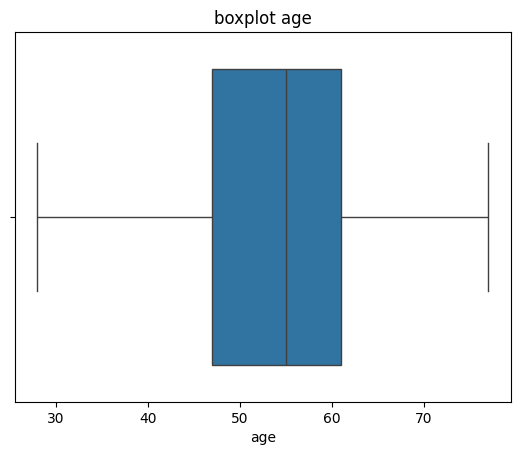

In [ ]:
sns.boxplot(x=df['age'])
plt.title('boxplot age')
plt.show()

# Min, Q1, Q2, Q3, Max sesuai dgn tabel

In [ ]:
num_cols = df.select_dtypes(include=['number']).columns
cat_cols = df.select_dtypes(include=['object']).columns

In [ ]:
print(f'data numerik : {num_cols}')
print(f'data kategorik : {cat_cols}')

data numerik : Index(['id', 'age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num'], dtype='object')
data kategorik : Index(['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal'], dtype='object')


In [ ]:
data_kosong = df.isnull().sum()

print(f'data_kosong \n{data_kosong}')

data_kosong 
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     99
chol         37
fbs         112
restecg       2
thalch       89
exang        89
oldpeak     116
slope       503
ca          923
thal        708
num           0
dtype: int64


In [ ]:
data_kosong = data_kosong[data_kosong > 0]

print(f'data yang kosong \n{data_kosong}')

data yang kosong 
trestbps     99
chol         37
fbs         112
restecg       2
thalch       89
exang        89
oldpeak     116
slope       503
ca          923
thal        708
dtype: int64


In [ ]:
data_duplkat = df.duplicated().sum()

print(f'data duplikat : {data_duplkat}')

data duplikat : 460


In [ ]:
df[df.duplicated()]

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
920,245,60,male,Cleveland,non-anginal,120.0,178.0,True,normal,96.0,False,0.0,upsloping,0.0,normal,0
921,31,69,male,Cleveland,typical angina,140.0,239.0,False,normal,151.0,False,1.8,upsloping,2.0,normal,0
922,295,63,female,Cleveland,asymptomatic,124.0,197.0,False,normal,136.0,True,0.0,flat,0.0,normal,1
923,315,34,male,Hungary,atypical angina,98.0,220.0,False,normal,150.0,False,0.0,NaN,NaN,NaN,0
924,45,61,female,Cleveland,asymptomatic,130.0,330.0,False,lv hypertrophy,169.0,False,0.0,upsloping,0.0,normal,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1375,797,49,male,VA Long Beach,typical angina,130.0,0.0,False,st-t abnormality,145.0,False,3.0,flat,NaN,NaN,2
1376,320,36,woman,Hungary,atypical angina,120.0,166.0,False,normal,180.0,False,0.0,NaN,NaN,NaN,0
1377,297,59,female,Cleveland,asymptomatic,164.0,176.0,True,lv hypertrophy,90.0,False,1.0,flat,2.0,fixed defect,3
1378,465,55,woman,Hungary,atypical angina,145.0,326.0,False,normal,155.0,False,0.0,NaN,NaN,NaN,0


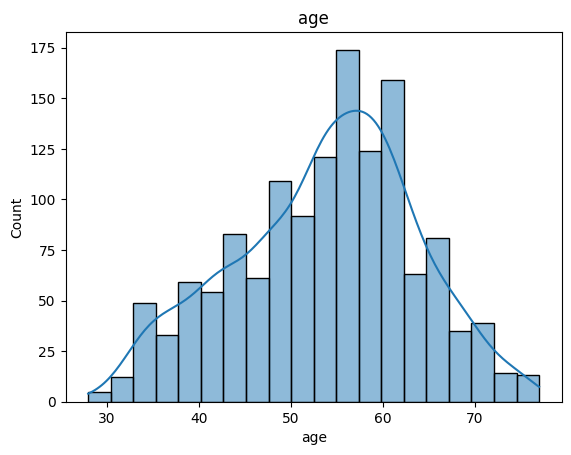

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['age'], kde= True)
plt.title('age')
plt.show()

# didapatkan hasil gaussian (condong ke tengah)

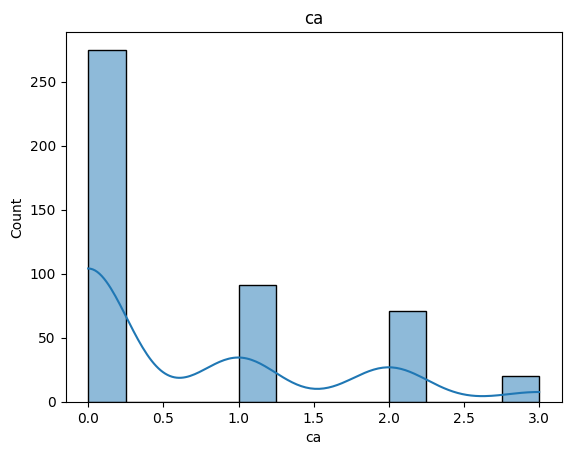

In [ ]:
sns.histplot(df['ca'], kde= True)
plt.title('ca')
plt.show()

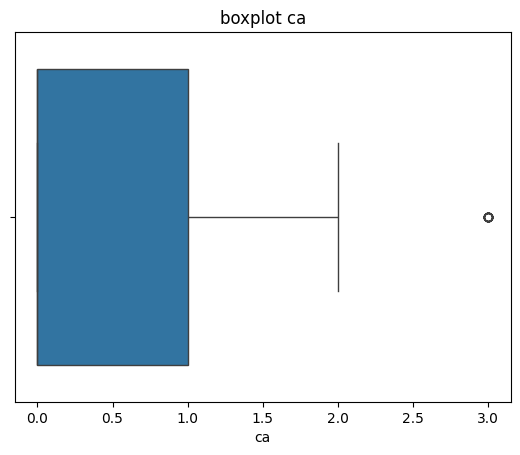

In [ ]:
sns.boxplot(x=df['ca'])
plt.title('boxplot ca')
plt.show()

In [ ]:
# kde = kernel distribusi entity

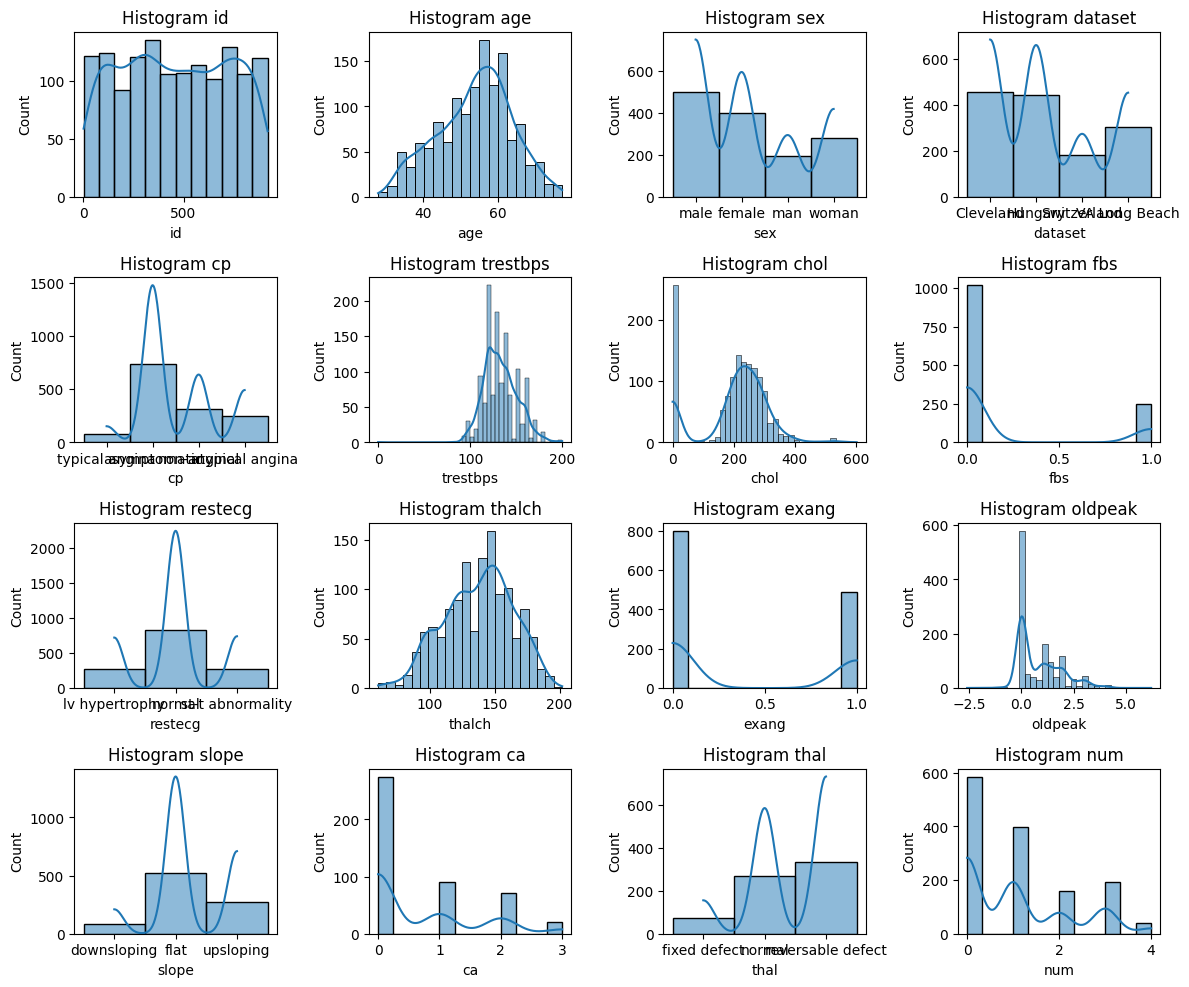

In [ ]:
plt.figure(figsize=(12, 12))

for i, col in enumerate(df.columns,1) :
  plt.subplot(5,4,i)
  sns.histplot(df[col], kde= True)
  plt.title(f'Histogram {col}')
plt.tight_layout()

plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

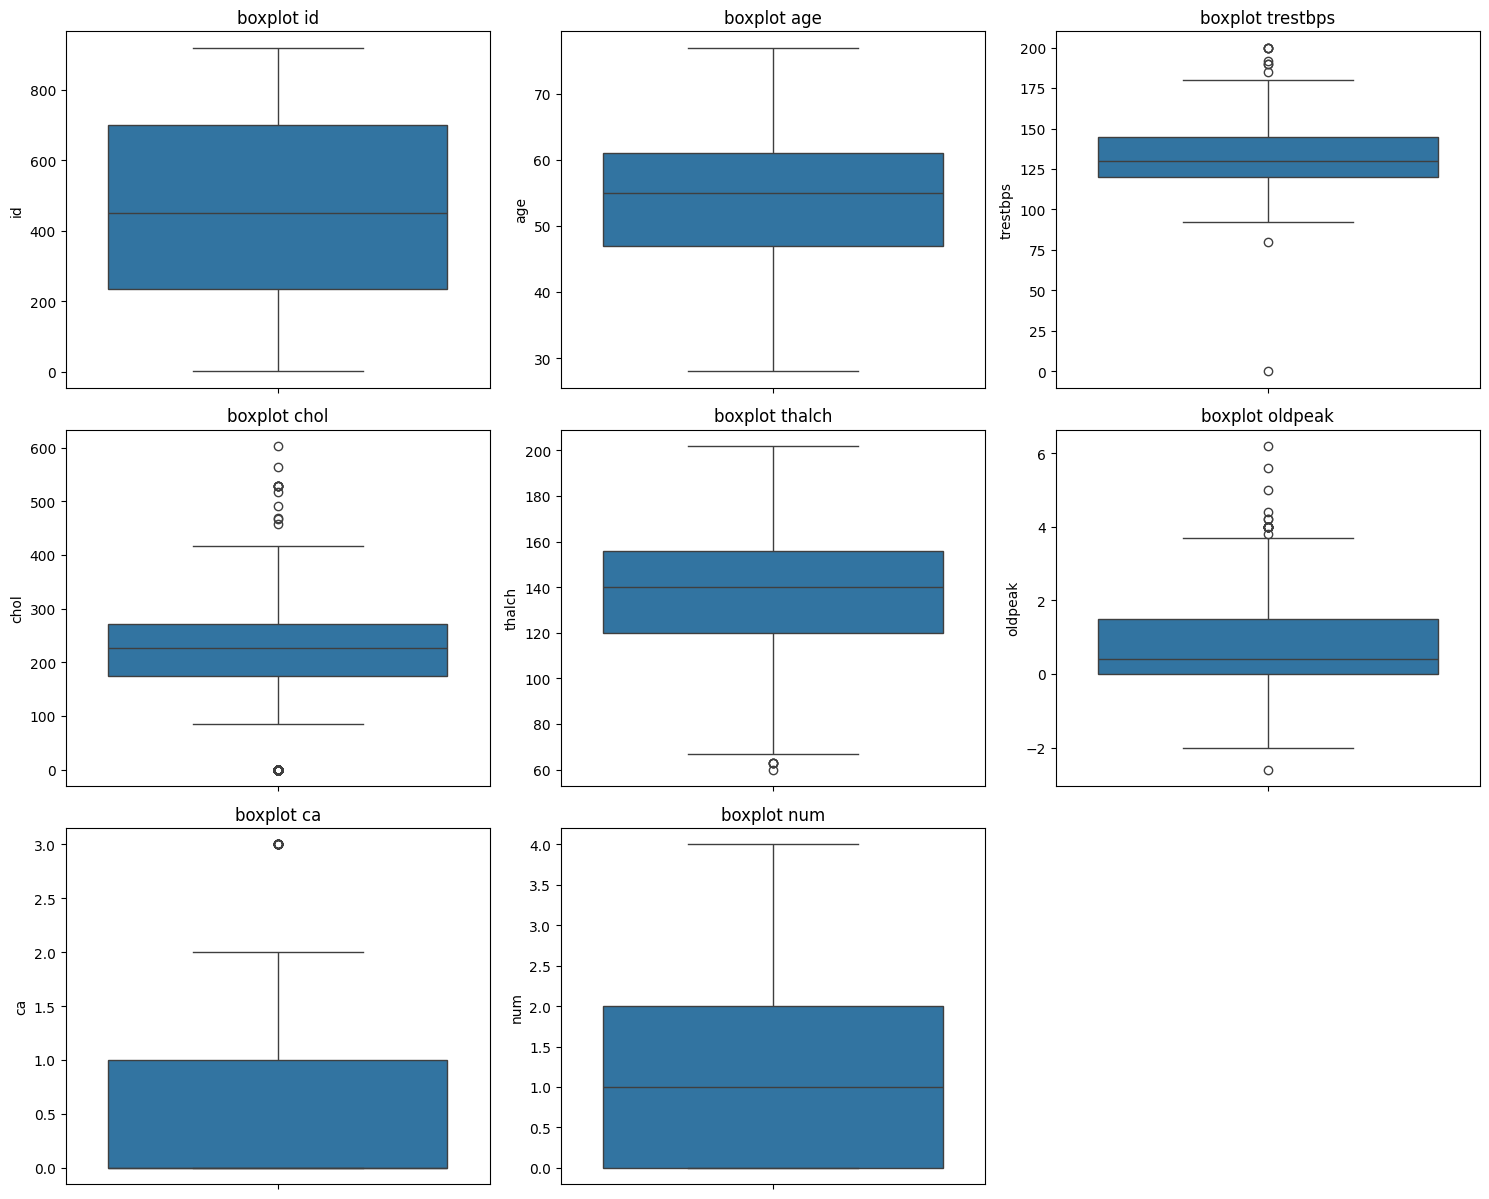

In [ ]:
import numpy as np

n_cols = 3

n_rows = int(np.ceil(len(df.columns) / n_cols))

plt.figure(figsize=(n_cols*5, n_rows*4))
for i, col in enumerate(num_cols, 1) :
  plt.subplot(n_rows, n_cols, i)
  sns.boxplot(df[col])
  plt.title(f'boxplot {col}')
plt.tight_layout()
plt.show

In [ ]:
df['sex'].unique()

array(['male', 'female', 'man', 'woman'], dtype=object)

In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

for col in cat_cols :
  print(f'Kolom {col}')
  print(df[col].unique())

Kolom sex
['male' 'female' 'man' 'woman']
Kolom dataset
['Cleveland' 'Hungary' 'Switzerland' 'VA Long Beach']
Kolom cp
['typical angina' 'asymptomatic' 'non-anginal' 'atypical angina']
Kolom fbs
[True False nan]
Kolom restecg
['lv hypertrophy' 'normal' 'st-t abnormality' nan]
Kolom exang
[False True nan]
Kolom slope
['downsloping' 'flat' 'upsloping' nan]
Kolom thal
['fixed defect' 'normal' 'reversable defect' nan]


**PRE PROCESSING DATA**

In [ ]:
df_new = df.copy()

In [ ]:
df_new['sex'] = df_new['sex'].replace(
    {
        'woman' : 'female',
        'man' : 'male'
    }
)

In [ ]:
print (f'before : {df['sex'].unique()}')
print (f'after : {df_new['sex'].unique()}')

before : ['male' 'female' 'man' 'woman']
after : ['male' 'female']


In [ ]:
df_new.duplicated().sum()

np.int64(460)

In [ ]:
print (f'total data asli : {df_new.shape[0]}')
print (f'total data duplikat : {df_new.duplicated().sum()}')

df_new.drop_duplicates(inplace=True)
print(f'total data setelah dibersihkan : {df_new.shape[0]}')

total data asli : 1380
total data duplikat : 460
total data setelah dibersihkan : 920


In [ ]:
df_new.isnull().sum().sum()

np.int64(1759)

In [ ]:
df_new = df_new.drop(['ca'], axis=1)

df_new.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,1,63,male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,fixed defect,0
1,2,67,female,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,normal,2
2,3,67,male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,reversable defect,1
3,4,37,male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,normal,0
4,5,41,male,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,normal,0


In [ ]:
df_null = df_new.isnull().sum()
df_null = df_null[df_null > 0]

df_null

,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55
exang,55
oldpeak,62
slope,309
thal,486


In [ ]:
df_new.isnull().sum().sum()

np.int64(1148)

In [ ]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  thal      434 non-null    object 
 14  num       920 non-null    int64  
dtypes: float64(4), int64(3), object(8)
memory usage: 115.0+ KB


In [ ]:
df_new['num'] = (df_new['num'] > 0).astype(int) # menggabungkan 1,2,3,4 menjadi 1

X = df_new.drop(['num', 'id'], axis=1)
y = df_new['num']

print(f'X : {X.shape}')
print(f'y : {y.shape}')

X : (920, 13)
y : (920,)


In [ ]:
df_new['num'].value_counts()

,count
num,
1,509
0,411


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train : {X_train.shape, y_train.shape}')
print(f'Test : {X_test.shape, y_test.shape}')


Train : ((736, 13), (736,))
Test : ((184, 13), (184,))


In [ ]:
# cek distribusi kelas di train

print("Distribusi kelas train")
print(y_train.value_counts(normalize=True).sort_index())

Distribusi kelas train
num
0    0.447011
1    0.552989
Name: proportion, dtype: float64


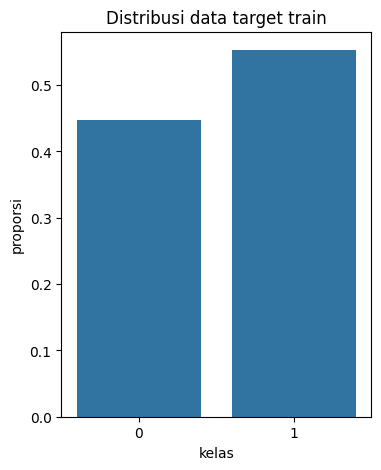

In [ ]:
plt.figure(figsize=(4, 5))
sns.barplot(x=y_train.value_counts(normalize=True).index, y=y_train.value_counts(normalize=True).values)

plt.title("Distribusi data target train")
plt.xlabel("kelas")
plt.ylabel("proporsi")
plt.show()

In [ ]:
# cek distribusi kelas di test

print("Distribusi kelas test")
print(y_test.value_counts(normalize=True).sort_index())

Distribusi kelas test
num
0    0.445652
1    0.554348
Name: proportion, dtype: float64


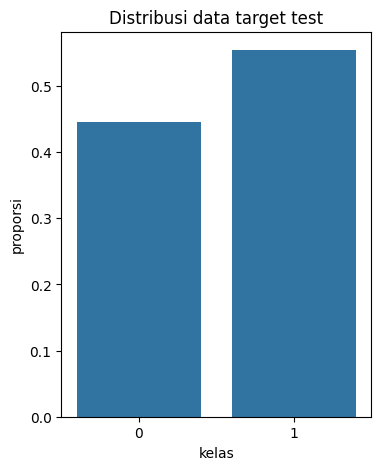

In [ ]:
plt.figure(figsize=(4, 5))
sns.barplot(x=y_test.value_counts(normalize=True).index, y=y_test.value_counts(normalize=True).values)

plt.title("Distribusi data target test")
plt.xlabel("kelas")
plt.ylabel("proporsi")
plt.show()

**PIPELINE** (buat preprocessing)

In [ ]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print(f'data numerik : {num_cols}')
print(f'data kategorik : {cat_cols}')

data numerik : ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
data kategorik : ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer

#Pipeline untuk kolom numerik: impute median + scaling
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


#pipeline untuk kolom kategorikal: impute modus + ordinal
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])


#Gabungkan ke ClumnTranformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
], remainder='drop') #kolom lain (kalau ada) dibuang

In [ ]:
from os import pipe
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', rf_clf)
])

pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalch', 'oldpeak']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['sex', 'dataset', 'cp',
                                                   'fbs', 'restecg', 'exang',
                                                   'slope', 'thal'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

In [ ]:
scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1_macro')
print(f'Scores : {scores}')
print(f'Mean Scores : {scores.mean()}')

oof_preds = cross_val_predict(pipe, X_train, y_train, cv=cv)
print(classification_report(y_train, oof_preds))

Scores : [0.76174242 0.75294118 0.81509434 0.79315197 0.81547259]
Mean Scores : 0.7876805006369988
              precision    recall  f1-score   support

           0       0.78      0.74      0.76       329
           1       0.80      0.83      0.82       407

    accuracy                           0.79       736
   macro avg       0.79      0.79      0.79       736
weighted avg       0.79      0.79      0.79       736



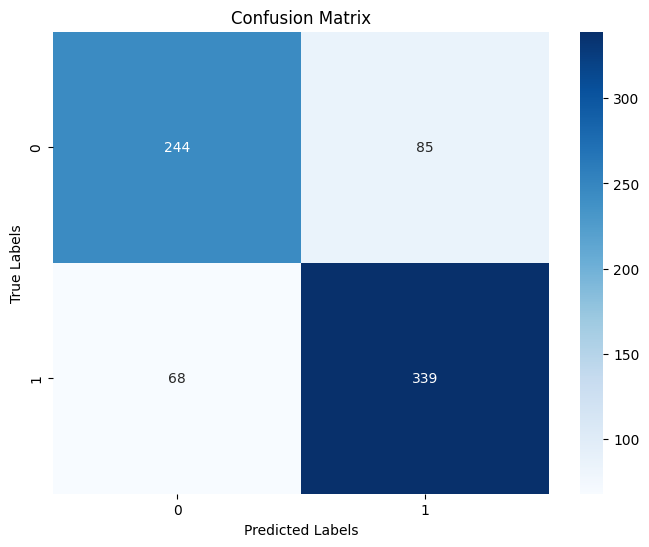

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_train, oof_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

**DATA TESTING**

In [ ]:
y_pred = pipe.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.79      0.82        82
           1       0.84      0.88      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



In [ ]:
from sklearn.model_selection import GridSearchCV

rf_clf = RandomForestClassifier(random_state=42,class_weight='balanced')

rf_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', rf_clf)
])

rf_params = {
    'classifier__n_estimators' : [100, 200, 300, 400, 500],
    'classifier__max_depth' : [None, 10],
    'classifier__class_weight' : [None, 'balanced', 'balanced_subsample'],
}

rf_search = GridSearchCV(rf_pipe, rf_params, cv=cv, scoring='f1_macro', verbose=2)
rf_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END classifier__class_weight=None, classifier__max_depth=None, classifier__n_estimators=100; total time=   0.4s
[CV] END classifier__class_weight=None, classifier__max_depth=None, classifier__n_estimators=100; total time=   0.4s
[CV] END classifier__class_weight=None, classifier__max_depth=None, classifier__n_estimators=100; total time=   0.4s
[CV] END classifier__class_weight=None, classifier__max_depth=None, classifier__n_estimators=100; total time=   0.3s
[CV] END classifier__class_weight=None, classifier__max_depth=None, classifier__n_estimators=100; total time=   0.3s
[CV] END classifier__class_weight=None, classifier__max_depth=None, classifier__n_estimators=200; total time=   0.4s
[CV] END classifier__class_weight=None, classifier__max_depth=None, classifier__n_estimators=200; total time=   0.5s
[CV] END classifier__class_weight=None, classifier__max_depth=None, classifier__n_estimators=200; total time=   0.5s
[C

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['age',
                                                                          'trestbps',
                                                                          'chol',
                                                                          'thalch',
                                                                          'oldpeak']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='m...
                                                                                                         unknown_value=-1))]),
                                                                         ['sex',
                                                                          'dataset',
                                                                          'cp',
                                                                          'fbs',
                                                                          'restecg',
                                                                          'exang',
                                                                          'slope',
                                                                          'thal'])])),
                                       ('classifier',
                                        RandomForestClassifier(class_weight='balanced',
                                                               random_state=42))]),
             param_grid={'classifier__class_weight': [None, 'balanced',
                                                      'balanced_subsample'],
                         'classifier__max_depth': [None, 10],
                         'classifier__n_estimators': [100, 200, 300, 400, 500]},
             scoring='f1_macro', verbose=2)

In [ ]:
print(rf_search.best_params_)
print(rf_search.best_score_)

{'classifier__class_weight': 'balanced', 'classifier__max_depth': None, 'classifier__n_estimators': 300}
0.7968535716160361


In [ ]:
y_pred = rf_search.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.80      0.82        82
           1       0.85      0.88      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.84      0.85       184
weighted avg       0.85      0.85      0.85       184



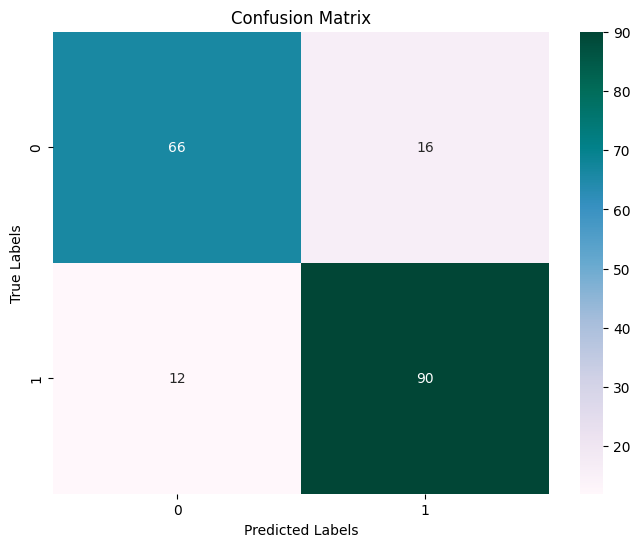

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="PuBuGn")
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as imbpipeline

smote = SMOTE(random_state=42, sampling_strategy='auto')

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

pipe = imbpipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", smote),
    ("classifier", rf_clf)
])

pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalch', 'oldpeak']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['sex', 'dataset', 'cp',
                                                   'fbs', 'restecg', 'exang',
                                                   'slope', 'thal'])])),
                ('smote', SMOTE(random_state=42)),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

In [ ]:
scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1_macro')
print(f'Scores : {scores}')
print(f'Mean Scores : {scores.mean()}')

oof_preds = cross_val_predict(pipe, X_train, y_train, cv=cv)
print(classification_report(y_train, oof_preds))

Scores : [0.76507937 0.77349769 0.82126824 0.78590557 0.78876373]
Mean Scores : 0.7869029183020888
              precision    recall  f1-score   support

           0       0.78      0.75      0.76       329
           1       0.80      0.83      0.81       407

    accuracy                           0.79       736
   macro avg       0.79      0.79      0.79       736
weighted avg       0.79      0.79      0.79       736



              precision    recall  f1-score   support

           0       0.84      0.80      0.82        82
           1       0.85      0.87      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



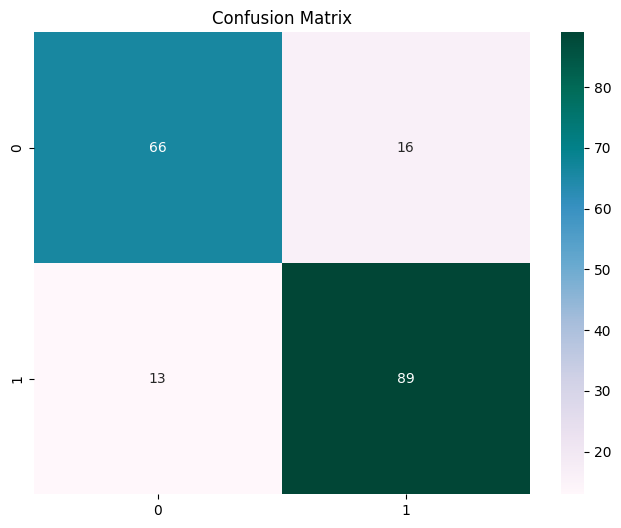

In [ ]:
y_pred = pipe.predict(X_test)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="PuBuGn")
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

rf_clf = RandomForestClassifier(random_state=42,class_weight='balanced')

rf_pipe = imbpipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', smote),
    ('classifier', rf_clf)
])

rf_params = {
    'classifier__n_estimators' : [100, 200, 300, 400, 500],
    'classifier__max_depth' : [None, 10],
    'classifier__class_weight' : [None, 'balanced', 'balanced_subsample'],
}

rf_search = GridSearchCV(rf_pipe, rf_params, cv=cv, scoring='f1_macro', verbose=1)
rf_search.fit(X_train, y_train)
print(rf_search.best_params_)
print(rf_search.best_score_)
y_pred = rf_search.predict(X_test)
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
{'classifier__class_weight': None, 'classifier__max_depth': 10, 'classifier__n_estimators': 300}
0.7949824593250262
              precision    recall  f1-score   support

           0       0.85      0.82      0.83        82
           1       0.86      0.88      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184

